In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
free_list = pd.read_csv("data/top50_free_games_list.csv")

free_list.head()

,AppID,Game Title,Release Date,Estimated Owners,Peak Concurrent Players (24h)
0,730,Counter-Strike 2,2012-08-21,100M+,1415913
1,570,Dota 2,2013-07-09,100M+,632090
2,578080,PUBG: BATTLEGROUNDS,2017-12-21,50M - 100M,798913
3,1172470,Apex Legends,2020-11-04,50M - 100M,277066
4,230410,Warframe,2013-03-25,50M - 100M,75491


In [5]:
free_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   AppID                          50 non-null     int64 
 1   Game Title                     50 non-null     object
 2   Release Date                   50 non-null     object
 3   Estimated Owners               50 non-null     object
 4   Peak Concurrent Players (24h)  50 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.1+ KB


In [6]:
free_list['Peak Concurrent Players (24h)'].describe()

count    5.000000e+01
mean     7.757702e+04
std      2.419688e+05
min      0.000000e+00
25%      3.597500e+02
50%      4.809500e+03
75%      2.283150e+04
max      1.415913e+06
Name: Peak Concurrent Players (24h), dtype: float64

In [7]:
free_list["Peak Concurrent Players (24h)"].mean()

np.float64(77577.02)

In [8]:
free_list["Peak Concurrent Players (24h)"].median()

4809.5

In [9]:
free_list["Peak Concurrent Players (24h)"].std()

241968.8243544804

**Games like CS2, Dota, PubG massively inflate the average that's why the mean is bigger than the median. The data is extremely skewed.**

<Axes: xlabel='Peak Concurrent Players (24h)', ylabel='Count'>

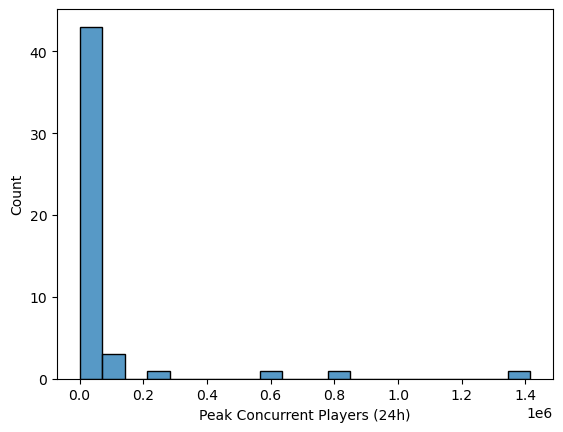

In [14]:
sns.histplot(free_list["Peak Concurrent Players (24h)"], bins=20)

**Some games are clustered low and there are some huge gigantic outliers as expected.**

In [16]:
paid_list = pd.read_csv("data/top50_paid_games_list.csv")
free_list["game_type"] = "Free"
paid_list["game_type"] = "Paid"
games = pd.concat([free_list, paid_list], ignore_index=True)
games.groupby("game_type")["Peak Concurrent Players (24h)"].describe()

,count,mean,std,min,25%,50%,75%,max
game_type,,,,,,,,
Free,50.0,77577.02,241968.824354,0.0,359.75,4809.5,22831.50,1415913.0
Paid,50.0,32735.64,35028.653910,2.0,9390.25,23735.0,40629.25,160154.0


**Compares median, mean, spread, and quantile of games. So we move on to free games**

In [18]:
free_players = pd.read_csv("data/top50_free_games_player_data.csv")
free_players.head()
free_players.columns

Index(['game_id', 'game_name', 'year_month', 'peak_player_count',
       'average_player_count'],
      dtype='object')

In [19]:
free_players.head()

,game_id,game_name,year_month,peak_player_count,average_player_count
0,730,Counter-Strike 2,2026-04,1564830,974785.71
1,730,Counter-Strike 2,2026-03,1717624,1069173.12
2,730,Counter-Strike 2,2026-02,1627561,1084094.59
3,730,Counter-Strike 2,2026-01,1654355,1070443.78
4,730,Counter-Strike 2,2025-12,1620137,991176.89


In [20]:
free_players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5015 entries, 0 to 5014
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   game_id               5015 non-null   int64  
 1   game_name             5015 non-null   object 
 2   year_month            5015 non-null   object 
 3   peak_player_count     5015 non-null   int64  
 4   average_player_count  5015 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 196.0+ KB


In [22]:
free_players = pd.read_csv("data/top50_free_games_player_data.csv")

free_players["year_month"] = pd.to_datetime(free_players["year_month"])

free_players = free_players.sort_values(
    by=["game_name", "year_month"]
)

free_players.head()

,game_id,game_name,year_month,peak_player_count,average_player_count
2589,113400,APB Reloaded,2012-07-01,4801,2482.45
2588,113400,APB Reloaded,2012-08-01,4876,2898.72
2587,113400,APB Reloaded,2012-09-01,4765,2466.85
2586,113400,APB Reloaded,2012-10-01,4350,2274.44
2585,113400,APB Reloaded,2012-11-01,4677,2297.09


In [23]:
first_obs = free_players.groupby("game_name").first()
last_obs = free_players.groupby("game_name").last()

retention = pd.DataFrame({
    "first_players": first_obs["average_player_count"],
    "last_players": last_obs["average_player_count"]
})

retention["retention_ratio"] = (
    retention["last_players"] / retention["first_players"]
)

retention.head()

,first_players,last_players,retention_ratio
game_name,,,
APB Reloaded,2482.45,225.48,0.090830
Action Taimanin,834.75,781.38,0.936065
AdVenture Capitalist,11629.53,1046.73,0.090006
Apex Legends,74957.26,124387.18,1.659441
BATTALION: Legacy,0.82,2.13,2.597561


In [24]:
retention.describe()

,first_players,last_players,retention_ratio
count,47.000000,47.000000,47.000000
mean,27583.861915,45855.449574,inf
std,102938.796265,160477.526411,NaN
min,0.000000,2.130000,0.000745
25%,102.545000,173.615000,0.089793
50%,2046.580000,704.730000,0.701306
75%,13935.000000,6141.870000,7.713640
max,699094.080000,974785.710000,inf


**mean and median retention, spread, and quartile**

In [25]:
retention = retention.replace([np.inf, -np.inf], np.nan)

In [26]:
retention = retention.dropna()

<Axes: xlabel='retention_ratio', ylabel='Count'>

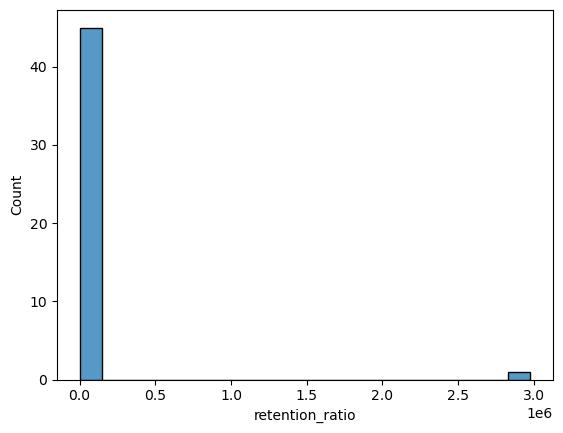

In [33]:
sns.histplot(retention["retention_ratio"], bins=20)

**Most games have zero early player counts, retention ratios becocame unstable/diverged because of some giagntic outliers making the data right skewed, so cleaning the data was necessary.**

In [34]:
retention.describe()

,first_players,last_players,retention_ratio
count,46.000000,46.000000,4.600000e+01
mean,28183.511087,45445.463043,6.521795e+04
std,103993.247178,162225.924075,4.388717e+05
min,0.010000,2.130000,7.452167e-04
25%,152.647500,157.167500,8.968704e-02
50%,2220.645000,676.450000,6.181627e-01
75%,15087.735000,5291.367500,7.187434e+00
max,699094.080000,974785.710000,2.977046e+06


**Like noted before the distribution is dominated by extreme outliers. Specifically the game with a retention of 2,977,046. Look up what game it is. A realistic conclusion is that our current retention metric is unstable for tiny initial values. This is a notable statistical issue a solution can be looking at the mean retention ratios for more conclusive data. The reason why this happens is most games lose players, some survive and some flop completely, a very tiny amount dominate the ecosystem.**

In [35]:
retention_clean = retention[
    retention["first_players"] > 100
]

In [36]:
retention_clean.describe()

,first_players,last_players,retention_ratio
count,35.000000,35.000000,35.000000
mean,37033.360857,57540.882571,31.521688
std,118221.328517,184688.860990,176.435892
min,105.120000,2.580000,0.000745
25%,1537.705000,286.035000,0.039950
50%,4488.140000,781.380000,0.195551
75%,18000.435000,6141.870000,1.404382
max,699094.080000,974785.710000,1045.268141


<Axes: xlabel='retention_ratio', ylabel='Count'>

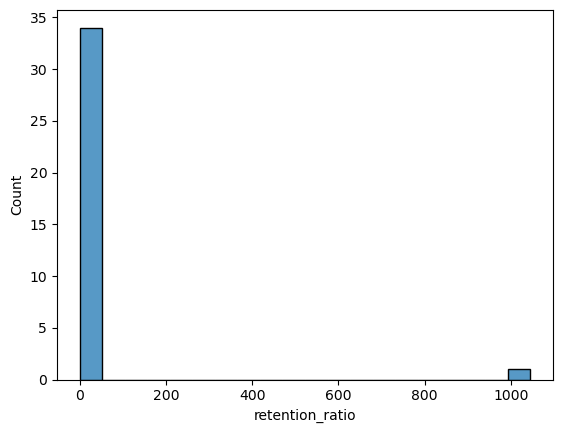

In [38]:
sns.histplot(retention_clean["retention_ratio"], bins=20)

**This gives us more conclusive data it shows that the he typical free to play game retains about 0.195551 or 19.6% of its original player base. Mean is still much larger than median meaning our earlier conclusion that some games decline substabstantially and some experience extreme long term growth. The value is still skewing the data to the rigt but it is to be expected. Maybe log transform can clean the data a bit more.**

In [43]:
retention["log_retention"] = np.log1p(
    retention["retention_ratio"]
)

<Axes: xlabel='log_retention', ylabel='Count'>

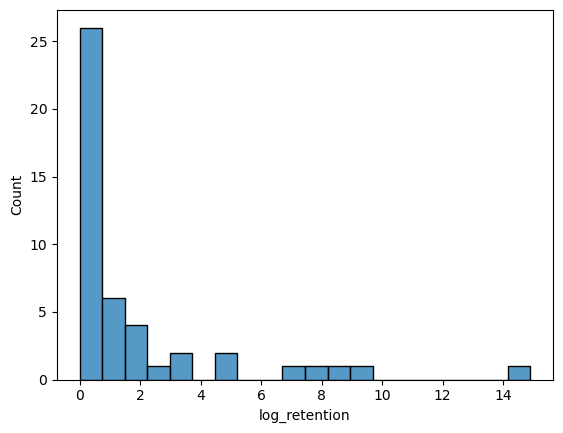

In [44]:
sns.histplot(retention["log_retention"], bins=20)

**Retention ratios for free to play games were highly skewed to the right, even after filtering extreme outliers. The log transformation improved visualization, though a small number of games still show extreme long term growth.**

----
**Now let's look at payed games**

In [45]:
paid_players = pd.read_csv("data/top50_paid_games_player_data.csv")

In [46]:
paid_players.head()

,game_id,game_name,year_month,peak_player_count,average_player_count
0,271590,Grand Theft Auto V Legacy,2026-04,108812,61797.66
1,271590,Grand Theft Auto V Legacy,2026-03,127424,69770.16
2,271590,Grand Theft Auto V Legacy,2026-02,127027,77909.39
3,271590,Grand Theft Auto V Legacy,2026-01,129542,80873.87
4,271590,Grand Theft Auto V Legacy,2025-12,136591,81832.19


In [47]:
paid_players["year_month"] = pd.to_datetime(paid_players["year_month"])

In [48]:
paid_players = paid_players.sort_values(
    by=["game_name", "year_month"]
)

In [49]:
first_obs_paid = paid_players.groupby(
    "game_name"
).first()
first_obs_paid.head()

,game_id,year_month,peak_player_count,average_player_count
game_name,,,,
Assetto Corsa,244210,2013-10-01,8,1.74
Battlefield V,1238810,2020-06-01,2034,1163.34
BeamNG.drive,284160,2014-08-01,272,88.27
Black Myth: Wukong,2358720,2024-08-01,2406967,970442.70
Borderlands 2,49520,2012-09-01,123596,61242.78


In [50]:
last_obs_paid = paid_players.groupby(
    "game_name"
).last()

last_obs_paid.head()

,game_id,year_month,peak_player_count,average_player_count
game_name,,,,
Assetto Corsa,244210,2026-04-01,18226,9828.48
Battlefield V,1238810,2026-04-01,10302,3868.19
BeamNG.drive,284160,2026-04-01,33575,19526.97
Black Myth: Wukong,2358720,2026-04-01,18778,7854.38
Borderlands 2,49520,2026-04-01,4585,2601.24


In [51]:
retention_paid = pd.DataFrame({
    "first_players":
        first_obs_paid["average_player_count"],

    "last_players":
        last_obs_paid["average_player_count"]
})

retention_paid.head()

,first_players,last_players
game_name,,
Assetto Corsa,1.74,9828.48
Battlefield V,1163.34,3868.19
BeamNG.drive,88.27,19526.97
Black Myth: Wukong,970442.70,7854.38
Borderlands 2,61242.78,2601.24


In [52]:
retention_paid["retention_ratio"] = (
    retention_paid["last_players"] /
    retention_paid["first_players"]
)

retention_paid.head()

,first_players,last_players,retention_ratio
game_name,,,
Assetto Corsa,1.74,9828.48,5648.551724
Battlefield V,1163.34,3868.19,3.325073
BeamNG.drive,88.27,19526.97,221.218647
Black Myth: Wukong,970442.70,7854.38,0.008094
Borderlands 2,61242.78,2601.24,0.042474


In [53]:
retention_paid = retention_paid.replace(
    [np.inf, -np.inf],
    np.nan
)

In [54]:
retention_paid = retention_paid.dropna()

In [55]:
retention_paid["log_retention"] = np.log1p(
    retention_paid["retention_ratio"]
)

In [56]:
retention_paid.describe()

,first_players,last_players,retention_ratio,log_retention
count,4.900000e+01,49.000000,49.000000,49.000000
mean,7.883749e+04,12647.086122,5395.636104,2.602776
std,2.185796e+05,17648.308243,24201.433513,3.581652
min,6.000000e-02,452.410000,0.001412,0.001411
25%,8.827000e+01,3293.290000,0.165461,0.153117
50%,8.395410e+03,6182.170000,1.092731,0.738470
75%,3.697641e+04,15422.370000,107.458227,4.686365
max,1.146060e+06,103351.800000,165713.875000,12.018024


<Axes: xlabel='log_retention', ylabel='Count'>

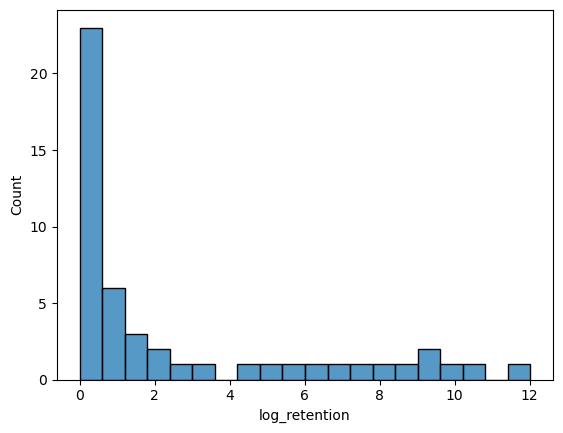

In [58]:
sns.histplot(retention_paid["log_retention"], bins=20)

* **I used ChatGPT to summarize conclusions** 

# Main Findings So Far

## 1. Retention distributions are extremely right-skewed

Both free-to-play and paid games showed highly skewed retention distributions.

This means:

* most games lose players over time
* a small number of games experience explosive long-term growth

A few highly successful games dominate the upper tail of the distribution, creating large outliers.

This was especially visible before the log transformation, where a handful of games stretched the entire scale.

---

# 2. Median retention is much more informative than the mean

The means were heavily distorted by extreme outliers.

For example:

* free games had a very large mean retention ratio despite most games declining substantially
* paid games also contained large outliers, though the overall distribution appeared more stable

Because of this skewness, the median retention ratio became a more reliable measure of a “typical” game’s performance.

---

# 3. Free-to-play games appear much more volatile

The free-to-play retention data showed:

* many games with very low retention
* several games with explosive growth
* extremely large variability overall

This suggests that free-to-play games may follow a “high-risk, high-reward” structure:

* many fail to sustain players
* a few become massive long-term ecosystems

Games like Apex Legends and Counter-Strike 2 likely contribute heavily to this pattern.

---

# 4. Paid games appear more stable overall

The paid games also showed skewness and outliers, but the center of the distribution appeared substantially higher.

One of the strongest findings so far is:

| Group      | Median Retention Ratio |
| ---------- | ---------------------- |
| Free Games | ~0.196                 |
| Paid Games | ~1.093                 |

Interpretation:

* the median free-to-play game retained only about 20% of its original player base
* the median paid game roughly maintained or slightly increased its player base over time

This suggests that paid games may have stronger long-term retention on average than free-to-play games.

---

# 5. Log transformations greatly improved visualization

The raw retention ratios were difficult to interpret because of extreme outliers.

Applying a log transformation:

* compressed massive values
* revealed the underlying distribution more clearly
* made comparisons between groups easier

Even after transformation, both distributions remained noticeably right-skewed, indicating that the skewness reflects a real property of the gaming market rather than simple data errors.

---

# 6. The data does not fully support the original expectation

Your proposal initially expected free-to-play games to potentially exhibit stronger long-term retention. 

However, the preliminary EDA suggests the opposite may be true:

* free-to-play games appear more volatile
* paid games appear more stable in terms of long-term player retention

This is an important result because meaningful statistical analysis does not always confirm the original hypothesis.

---

# Overall Interpretation

The Steam ecosystem appears highly unequal:

* most games lose players over time
* a few games dominate attention and sustain enormous player bases

Free-to-play games appear capable of extraordinary growth, but many also experience severe player decline.

Paid games appear less explosive overall, but potentially more stable in retaining long-term player communities.

These findings set up the next stage of the project:

* formal statistical comparisons
* hypothesis testing
* regression analysis
* investigation of factors influencing retention.


**Comparison Box Plot**

In [61]:
retention["game_type"] = "Free"

retention_paid["game_type"] = "Paid"

In [62]:
retention_all = pd.concat(
    [retention, retention_paid]
)

<Axes: xlabel='game_type', ylabel='log_retention'>

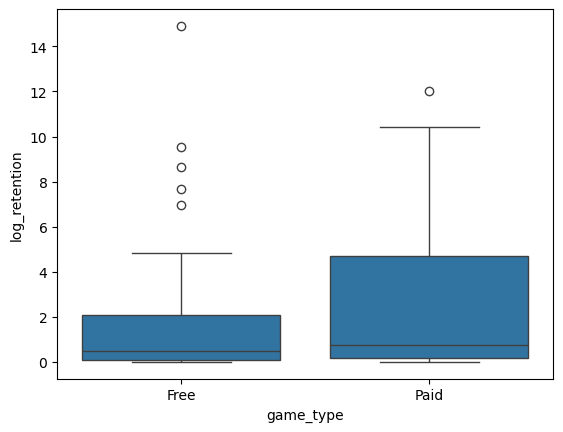

In [64]:
sns.boxplot(
    x="game_type",
    y="log_retention",
    data=retention_all
)

# Conclusions from box plot:
***I used ChatGPT but added some of my own conclusions**

## 1. Paid games appear to have higher typical retention

The median line for paid games is visibly higher than the median for free games.
That supports your earlier numerical findings:

* the “typical” paid game appears to retain players better over time
* free games more often experience substantial decline

---

# 2. Paid games also show larger spread

The paid-game box is taller, meaning:

* the interquartile range is larger
* paid games vary substantially in long-term performance

Interpretation:

* some paid games flop
* others become highly succesful over time

---

# 3. Free games appear more concentrated near low retention

Most free games cluster near the bottom of the distribution.

Interpretation:

* many free to play games struggle to maintain long term engagement
* only a small number become major long term successes

This fits a “high risk/high reward” pattern for game developers.

---

# 4. Both groups contain major outliers

Both free and paid games contain extremely large positive outliers. Most likely:

* breakout games. Usually gain popularity from streamers and social media. This one creates the biggest growth and
the enormous retention rates. 
* Game that foster community. Players tend to return regurlarly, play with friends, and invest thousands of hours.
* live service phenomena. Games that feature battle passes, seasons, events, expansions, esports, etc. 
* cult following games. Usually games that include modding like Terraria or Stardew Valley. They tend to maintain
players for many years and gain players slowly over time.

The outliers demonstrate that:

* Steam retention is highly unequal
* a small number of games dominate long term attention

---

# 5. The log transformation 

Without the log transform:

* the distributions were almost impossible to compare

After transformation:

* medians
* spreads
* outliers

became much easier to interpret visually.

This was absolutely the correct statistical choice.

---

# IMPORTANT INTERPRETATION

One subtle but important thing:

The paid-game distribution seems shifted upward overall.

That means:

* not only are there extreme paid game successes,
* but the entire distribution appears healthier.

That is stronger evidence than just comparing one or two giant outliers.

---

# Conclusion so far:

> Free-to-play games are capable of explosive growth, but the typical free game experiences substantial long term decline. Paid games appear more stable overall and may retain players more consistently over time.

---

